<a href="https://colab.research.google.com/github/Manish-248/Machine-Learning-with-Scikit-learn-End-to-End-Workflow/blob/main/Notebook/Machine_Learning_Fundamentals_with_Scikit_learn_End_to_End_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
Machine Learning Fundamentals with Scikit-learn
Author: Manish Chandra
Description: End-to-end ML workflow including preprocessing, modeling, and PCA.
"""

# 📊 Machine Learning Pipeline using Scikit-learn (Iris Dataset)

## 🎯 Objective
This notebook demonstrates an end-to-end machine learning workflow using Scikit-learn.  
We will cover the complete pipeline from data loading to model evaluation and dimensionality reduction.

## 📌 Workflow Steps
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training (KNN)
5. Model Evaluation
6. Dimensionality Reduction (PCA)
7. Model Saving & Loading

## 📁 Dataset
We use the famous **Iris dataset**, a classic dataset in machine learning.

## 🛠️ Tools & Libraries
- Pandas
- NumPy
- Matplotlib / Seaborn
- Scikit-learn

---

💡 This notebook is designed to be:
- Clean and well-documented
- Beginner-friendly
- Portfolio-ready

# ================================
# 📦 IMPORT REQUIRED LIBRARIES
# ================================

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn datasets and tools
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Model Saving
import joblib

# Display settings for better readability
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully")

In [34]:
# ============================================
# 📥 LOAD IRIS DATASET AND CONVERT TO DATAFRAME
# ============================================

# Import necessary libraries for this cell
from sklearn.datasets import load_iris
import pandas as pd

# Load dataset from sklearn
iris = load_iris()

# Convert to DataFrame for better handling
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add target column
df['target'] = iris.target

# Map target values to actual species names
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# Display first few rows
print("🔍 Preview of Dataset:")
display(df.head())

# Basic shape of dataset
print("\n📐 Dataset Shape:", df.shape)

🔍 Preview of Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



📐 Dataset Shape: (150, 6)


In [35]:
# ============================================
# 🔍 BASIC DATA EXPLORATION
# ============================================

print("📌 Dataset Info:")
df.info()

print("\n📊 Statistical Summary:")
display(df.describe())

print("\n🔢 Value Counts (Target):")
print(df['species'].value_counts())

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

📊 Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



🔢 Value Counts (Target):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [36]:
# ============================================
# 🔍 BASIC DATA EXPLORATION
# ============================================

print("📌 Dataset Info:")
df.info()

print("\n📊 Statistical Summary:")
display(df.describe())

print("\n🔢 Value Counts (Target):")
print(df['species'].value_counts())

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

📊 Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



🔢 Value Counts (Target):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


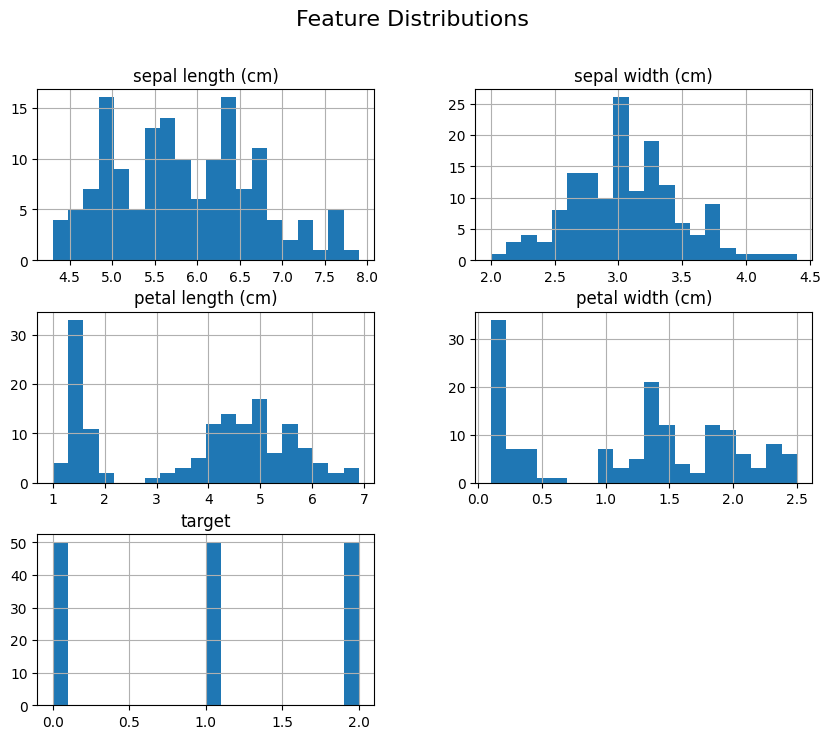

In [37]:
# ============================================
# 📊 UNIVARIATE ANALYSIS (Feature Distribution)
# ============================================

import matplotlib.pyplot as plt

df.hist(figsize=(10, 8), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

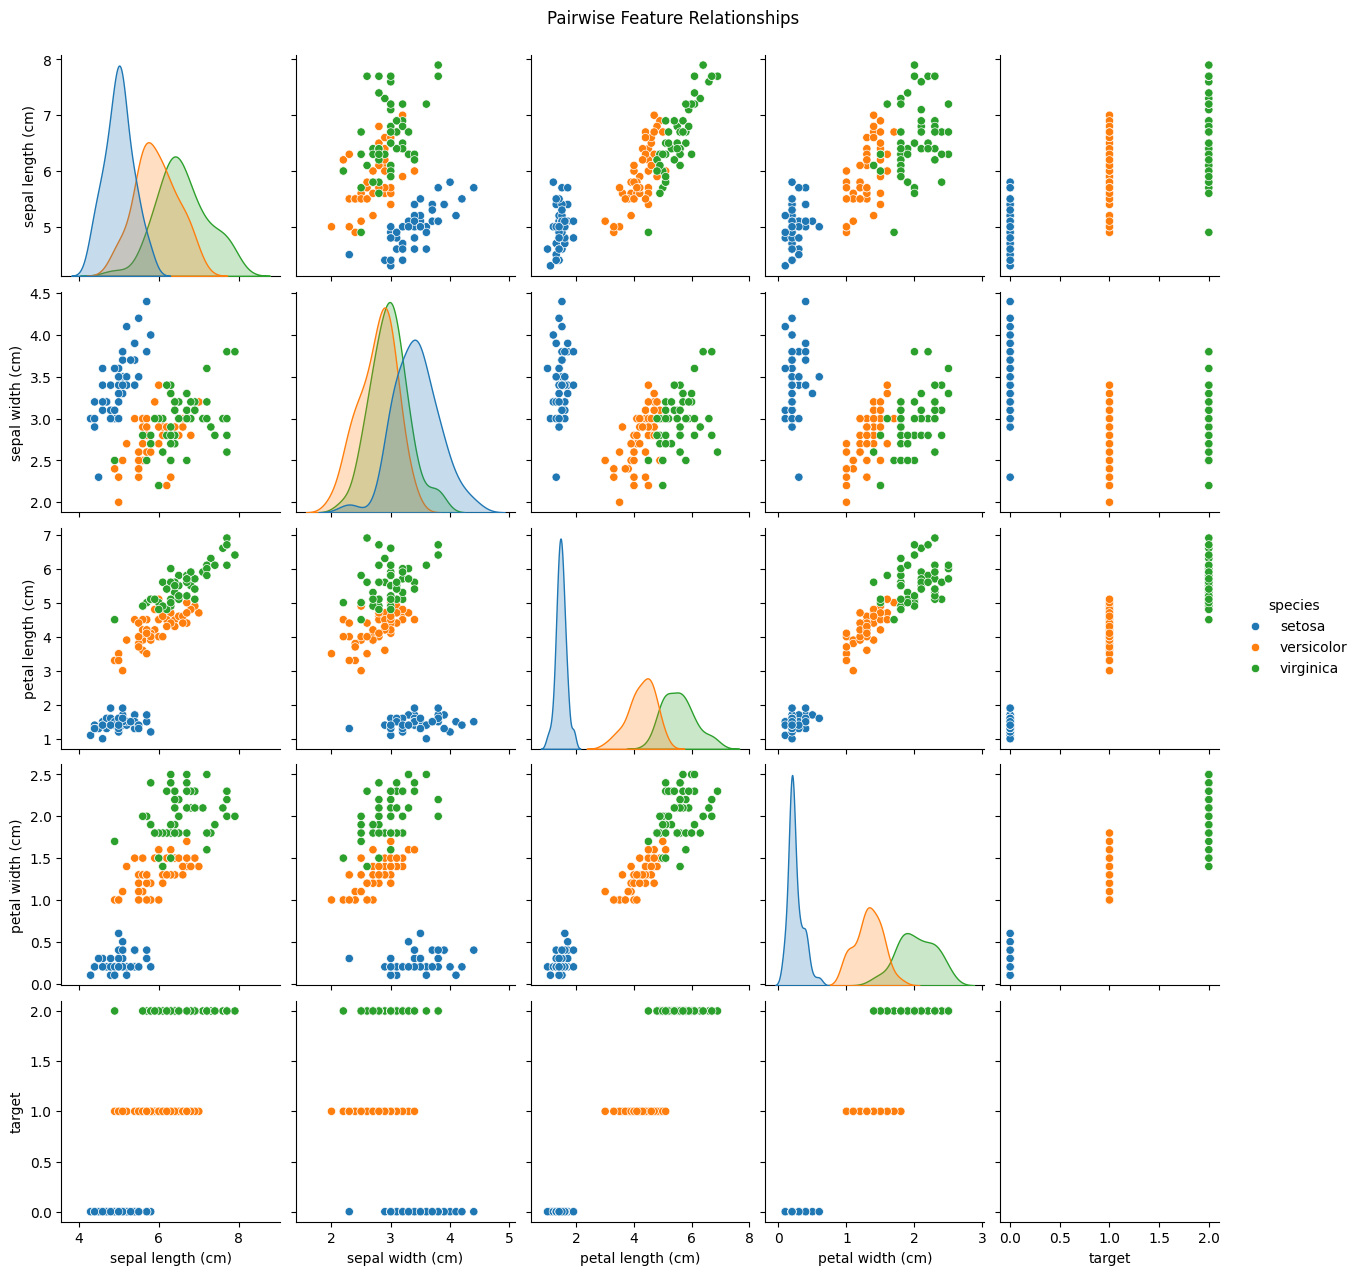

In [38]:
# ============================================
# 🔗 BIVARIATE ANALYSIS (RELATIONSHIPS)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df, hue='species')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

## 📊 Univariate Analysis (Box Plots for Feature Distribution)

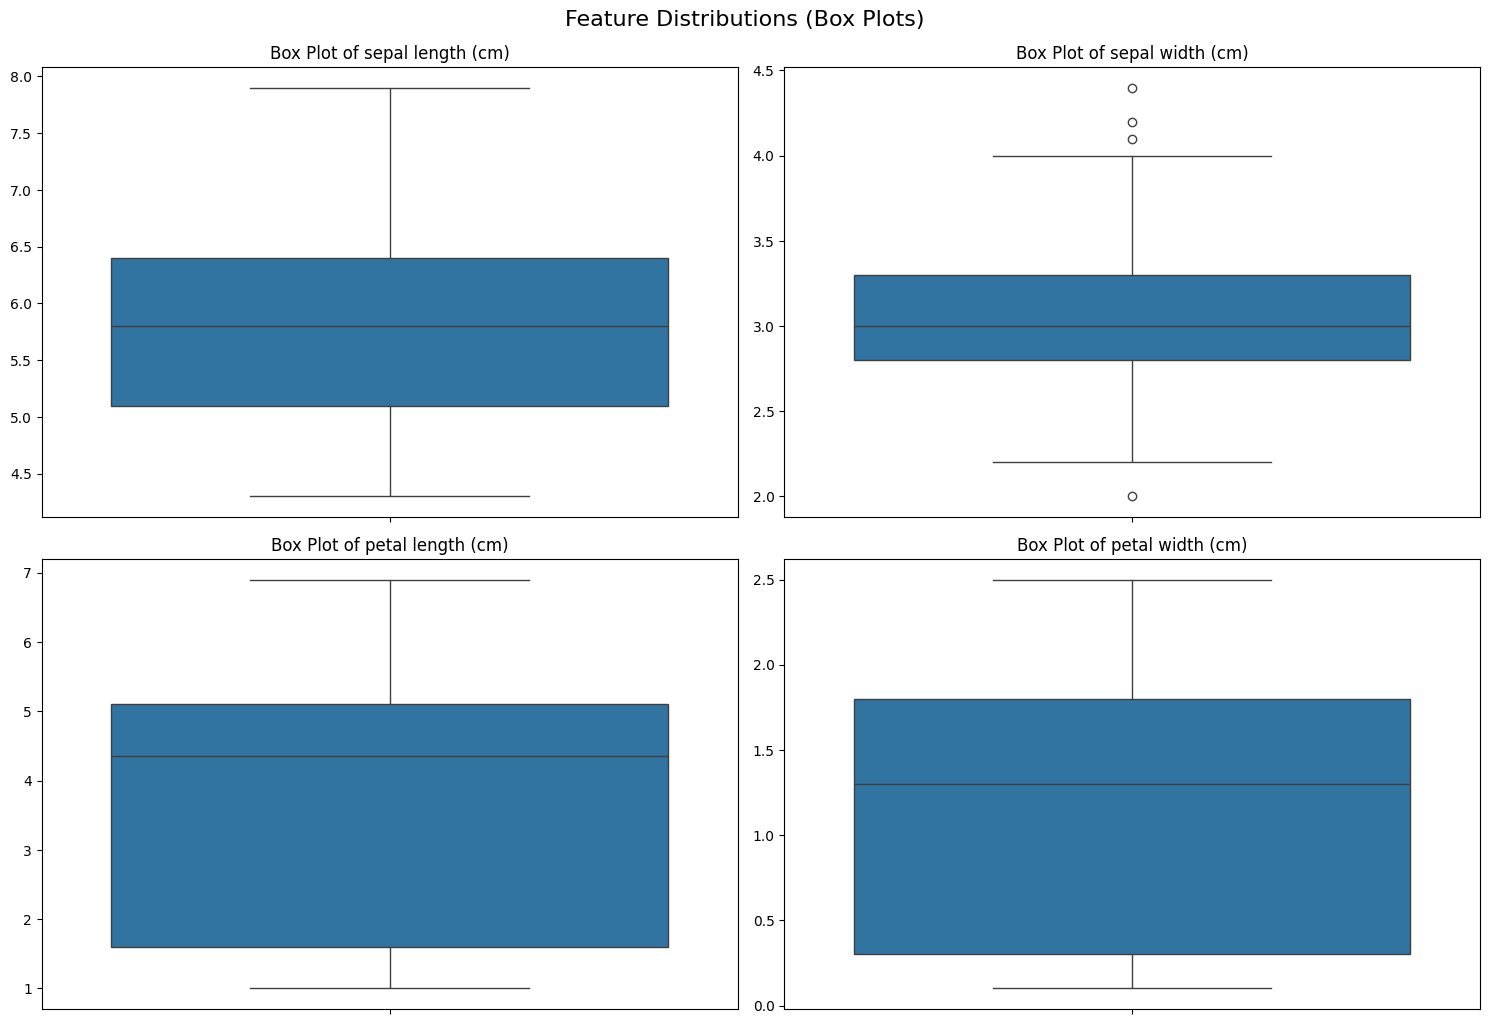

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature columns from df, excluding 'target' and 'species'
feature_cols = df.drop(columns=['target', 'species']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col]) # Use df[col] to access data by column name
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label as title is descriptive enough
plt.tight_layout()
plt.suptitle('Feature Distributions (Box Plots)', y=1.02, fontsize=16)
plt.show()

In [40]:
# ============================================
# 🎯 FEATURE & TARGET SEPARATION
# ============================================

# Features (independent variables)
X = df.drop(['target', 'species'], axis=1)

# Target (dependent variable)
y = df['target']

print("📌 Feature Matrix Shape:", X.shape)
print("📌 Target Vector Shape:", y.shape)

display(X.head())

📌 Feature Matrix Shape: (150, 4)
📌 Target Vector Shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [41]:
# ============================================
# ✂️ TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset from sklearn
iris = load_iris()

# Convert to DataFrame for better handling
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add target column
df['target'] = iris.target

# Map target values to actual species names
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# Features (independent variables)
X = df.drop(['target', 'species'], axis=1)

# Target (dependent variable)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("📊 Training Data Shape:", X_train.shape)
print("📊 Testing Data Shape:", X_test.shape)

📊 Training Data Shape: (120, 4)
📊 Testing Data Shape: (30, 4)


In [42]:
# ============================================
# 📊 FEATURE DISTRIBUTION SUMMARY
# ============================================

print("📊 Statistical Summary of Features:")
display(df.describe())

📊 Statistical Summary of Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Summary of Feature Distributions

The `df.describe()` output provides key statistical insights into the numerical features of the Iris dataset:

*   **Count:** All features ('sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target') have 150 non-null entries, indicating no missing values in these columns.
*   **Mean:**
    *   `sepal length (cm)`: Average length is around 5.84 cm.
    *   `sepal width (cm)`: Average width is around 3.05 cm.
    *   `petal length (cm)`: Average length is around 3.76 cm.
    *   `petal width (cm)`: Average width is around 1.20 cm.
*   **Standard Deviation (std):** This indicates the spread of the data. `sepal length (cm)` and `petal length (cm)` show larger standard deviations, suggesting more variation compared to `sepal width (cm)` and `petal width (cm)`.
*   **Min and Max:** These values show the full range of each feature.
    *   `sepal length (cm)` ranges from 4.3 to 7.9 cm.
    *   `sepal width (cm)` ranges from 2.0 to 4.4 cm.
    *   `petal length (cm)` ranges from 1.0 to 6.9 cm.
    *   `petal width (cm)` ranges from 0.1 to 2.5 cm.
*   **25th, 50th (Median), and 75th Percentiles:** These quartiles provide insight into the data distribution.
    *   The median (`50%`) is often close to the mean, but slight differences (e.g., for `petal length (cm)`) can suggest some skewness in the distribution.
    *   The difference between the 75th and 25th percentiles (Interquartile Range - IQR) gives a sense of the central spread of the data.

Overall, the numerical features are well-behaved with no extreme outliers immediately visible from this summary, and the target variable has a range from 0 to 2, confirming the three classes of Iris species.

In [43]:
# ============================================
# ⚙️ DATA PREPROCESSING (SCALING METHODS)
# ============================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# Standardization (Mean=0, Std=1)
scaler_standard = StandardScaler()
X_train_std = scaler_standard.fit_transform(X_train)
X_test_std = scaler_standard.transform(X_test)

# Min-Max Scaling (0 to 1)
scaler_minmax = MinMaxScaler()
X_train_mm = scaler_minmax.fit_transform(X_train)
X_test_mm = scaler_minmax.transform(X_test)

# Normalization (unit norm)
normalizer = Normalizer()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

print("✅ Preprocessing completed")

print("\n🔹 Example (Standardized Data):")
print(X_train_std[:3])

✅ Preprocessing completed

🔹 Example (Standardized Data):
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]]


## 🤖 Model Training (K-Nearest Neighbors)

In [44]:
# ============================================
# 🤖 MODEL TRAINING (K-NEAREST NEIGHBORS)
# ============================================

from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier with n_neighbors=5 (common choice)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the model using the standardized training data
knn_classifier.fit(X_train_std, y_train)

print("✅ KNN Classifier trained successfully on standardized data.")

✅ KNN Classifier trained successfully on standardized data.


In [45]:
# ============================================================
# SECTION: Scikit-learn Estimator API (Core ML Workflow)
# ============================================================

"""
In this section, we implement the core Machine Learning workflow using Scikit-learn.

We will learn:
1. What is an Estimator
2. How fit(), predict(), transform() work
3. How to build a complete ML pipeline

This is the MOST IMPORTANT concept in Scikit-learn.
"""

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

"""
We use the built-in Iris dataset.
"""

iris = load_iris()

X = iris.data
y = iris.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


# ============================================================
# STEP 3: TRAIN-TEST SPLIT
# ============================================================

"""
We split the data into training and testing sets.
"""

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


# ============================================================
# STEP 4: UNDERSTANDING ESTIMATOR (fit)
# ============================================================

"""
Estimator = Any ML model (e.g., KNN, Linear Regression)

fit() = Learns from data
"""

model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

print("Model training completed using fit()")


# ============================================================
# STEP 5: PREDICTION (predict)
# ============================================================

"""
predict() = Make predictions on new/unseen data
"""

y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])


# ============================================================
# STEP 6: MODEL EVALUATION
# ============================================================

"""
Evaluate how well the model performs
"""

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)


# ============================================================
# STEP 7: DATA TRANSFORMATION (StandardScaler)
# ============================================================

"""
transform() = Modify data (e.g., scaling)

Important:
- Scaling improves model performance
- Especially important for distance-based models (like KNN)
"""

scaler = StandardScaler()

# Fit + Transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data (DO NOT fit again!)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed")


# ============================================================
# STEP 8: TRAIN MODEL ON SCALED DATA
# ============================================================

model_scaled = KNeighborsClassifier(n_neighbors=3)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Accuracy after scaling:", accuracy_scaled)


# ============================================================
# STEP 9: PIPELINE (BEST PRACTICE)
# ============================================================

"""
Pipeline = Automates preprocessing + modeling

This is the INDUSTRY STANDARD way
"""

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Predict
y_pred_pipeline = pipeline.predict(X_test)

# Evaluate
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)

print("Pipeline Accuracy:", accuracy_pipeline)


# ============================================================
# FINAL SUMMARY
# ============================================================

"""
Key Learnings:

1. fit() → trains the model
2. predict() → makes predictions
3. transform() → preprocesses data
4. Pipeline → combines steps efficiently

This structure is used in REAL-WORLD ML systems.
"""

Feature matrix shape: (150, 4)
Target vector shape: (150,)
Training data shape: (120, 4)
Testing data shape: (30, 4)
Model training completed using fit()
Predictions: [1 0 2 1 1 0 1 2 1 1]
Model Accuracy: 1.0
Data scaling completed
Accuracy after scaling: 1.0
Pipeline Accuracy: 1.0


'\nKey Learnings:\n\n1. fit() → trains the model\n2. predict() → makes predictions\n3. transform() → preprocesses data\n4. Pipeline → combines steps efficiently\n\nThis structure is used in REAL-WORLD ML systems.\n'

In [46]:
# ============================================================
# SECTION: Linear Models (Regression & Classification)
# ============================================================

"""
In this section, we explore Linear Models:

1. Linear Regression (for continuous prediction)
2. Logistic Regression (for classification)
3. Ridge & Lasso (regularization techniques)

These are fundamental ML models widely used in industry.
"""

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris, make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, accuracy_score


# ============================================================
# PART 1: LINEAR REGRESSION
# ============================================================

"""
Linear Regression predicts continuous values.

We generate synthetic data for demonstration.
"""

# Create synthetic regression dataset
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train model
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# Predict
y_pred_reg = lin_reg.predict(X_test_reg)

# Evaluate
mse = mean_squared_error(y_test_reg, y_pred_reg)

print("Linear Regression MSE:", mse)


# ============================================================
# PART 2: LOGISTIC REGRESSION (CLASSIFICATION)
# ============================================================

"""
Logistic Regression is used for classification problems.
"""

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Binary classification (simplify problem)
X_binary = X[y != 2]
y_binary = y[y != 2]

# Train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

# Train Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_clf, y_train_clf)

# Predict
y_pred_clf = log_reg.predict(X_test_clf)

# Evaluate
accuracy = accuracy_score(y_test_clf, y_pred_clf)

print("Logistic Regression Accuracy:", accuracy)


# ============================================================
# PART 3: REGULARIZATION (RIDGE & LASSO)
# ============================================================

"""
Regularization helps prevent overfitting.

Ridge → L2 Regularization
Lasso → L1 Regularization
"""

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg, y_train_reg)

y_pred_ridge = ridge.predict(X_test_reg)
ridge_mse = mean_squared_error(y_test_reg, y_pred_ridge)

print("Ridge Regression MSE:", ridge_mse)


# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_reg, y_train_reg)

y_pred_lasso = lasso.predict(X_test_reg)
lasso_mse = mean_squared_error(y_test_reg, y_pred_lasso)

print("Lasso Regression MSE:", lasso_mse)


# ============================================================
# FINAL SUMMARY
# ============================================================

"""
Key Learnings:

1. Linear Regression → Continuous output prediction
2. Logistic Regression → Classification problems
3. Ridge → Shrinks coefficients (L2)
4. Lasso → Feature selection (L1)

These models are essential for understanding ML fundamentals.
"""

Linear Regression MSE: 246.12179288664484
Logistic Regression Accuracy: 1.0
Ridge Regression MSE: 248.48545064786853
Lasso Regression MSE: 246.499305285591


'\nKey Learnings:\n\n1. Linear Regression → Continuous output prediction\n2. Logistic Regression → Classification problems\n3. Ridge → Shrinks coefficients (L2)\n4. Lasso → Feature selection (L1)\n\nThese models are essential for understanding ML fundamentals.\n'

Original Shape: (150, 4)
Reduced Shape: (150, 2)
Explained Variance Ratio: [0.72962445 0.22850762]


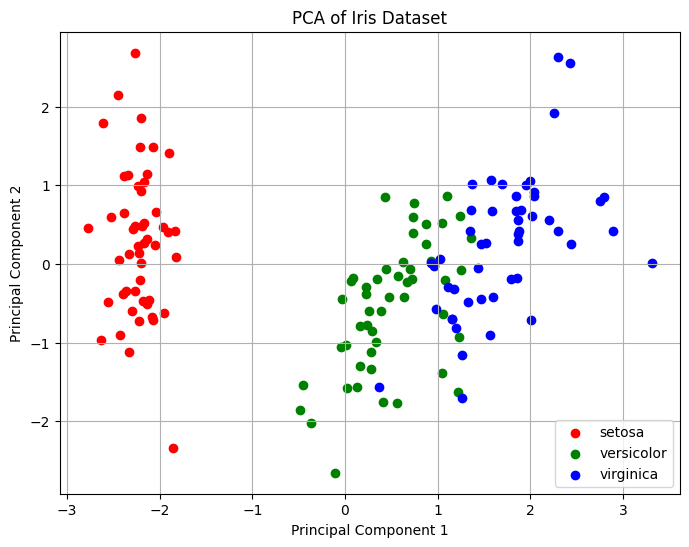

'\nKey Learnings:\n\n1. PCA reduces dimensionality\n2. Keeps maximum variance (information)\n3. Helps visualization of complex data\n4. Requires feature scaling before use\n\nThis is widely used in real-world ML pipelines.\n'

In [47]:
# ============================================================
# SECTION: PCA (Principal Component Analysis)
# ============================================================

"""
In this section, we perform dimensionality reduction using PCA.

PCA transforms high-dimensional data into fewer dimensions
while preserving maximum variance.

Use cases:
- Data compression
- Visualization
- Noise reduction
"""

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# ============================================================
# STEP 2: LOAD DATA
# ============================================================

iris = load_iris()
X = iris.data
y = iris.target

print("Original Shape:", X.shape)


# ============================================================
# STEP 3: FEATURE SCALING (VERY IMPORTANT)
# ============================================================

"""
PCA is affected by scale → so we standardize data first
"""

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ============================================================
# STEP 4: APPLY PCA (REDUCE TO 2 DIMENSIONS)
# ============================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Reduced Shape:", X_pca.shape)


# ============================================================
# STEP 5: EXPLAINED VARIANCE
# ============================================================

"""
Explained variance tells how much information is retained
"""

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


# ============================================================
# STEP 6: VISUALIZATION
# ============================================================

"""
Visualizing PCA output (2D projection)
"""

plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']

for i, color in enumerate(colors):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        label=iris.target_names[i],
        color=color
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

"""
Key Learnings:

1. PCA reduces dimensionality
2. Keeps maximum variance (information)
3. Helps visualization of complex data
4. Requires feature scaling before use

This is widely used in real-world ML pipelines.
"""